# Energy Consumption Prediction

## Data Loading

In [14]:
import pandas as pd

In [15]:
df = pd.read_csv("cleaned_energy_dataset.csv")
df.head()

,Month,Hour,DayOfWeek,Holiday,Temperature,Humidity,SquareFootage,Occupancy,HVACUsage,LightingUsage,RenewableEnergy,EnergyConsumption
0,8,10,6,0,23.951,44.511,1339.234,4.158,0.0,1.0,21.512,83.136
1,7,6,5,1,25.341,33.366,1966.729,3.159,1.0,1.0,7.298,80.181
2,2,17,1,1,21.945,27.862,1150.873,0.957,0.0,1.0,6.695,80.972
3,12,12,4,0,25.131,63.267,1320.303,5.174,1.0,0.0,11.069,84.931
4,10,17,4,1,28.738,33.270,1950.890,7.581,0.0,0.0,11.307,92.539


In [16]:
# Libraries
import matplotlib.pyplot as plt
import seaborn as sns

## Dataset Overview

In [17]:
df.shape

(118740, 12)

In [18]:
df.describe()

,Month,Hour,DayOfWeek,Holiday,Temperature,Humidity,SquareFootage,Occupancy,HVACUsage,LightingUsage,RenewableEnergy,EnergyConsumption
count,118740.000000,118740.000000,118740.000000,118740.000000,118740.000000,118740.000000,118740.000000,118740.000000,118740.000000,118740.000000,118740.000000,118740.000000
mean,6.218747,11.518225,3.071720,0.455407,24.910237,45.490245,1506.407835,4.568997,0.497573,0.490116,15.171466,76.671918
std,3.596111,6.876368,1.973193,0.498010,3.067992,9.101676,298.091373,2.879254,0.492687,0.492687,9.056827,8.978039
min,1.000000,0.000000,0.000000,0.000000,18.119000,24.246000,826.477000,-0.381000,0.000000,0.000000,0.005000,53.957000
25%,3.000000,6.000000,1.000000,0.000000,22.476000,38.319000,1259.239000,2.027000,0.000000,0.000000,7.635000,70.331000
50%,6.000000,11.000000,3.000000,0.000000,24.937357,45.478235,1507.548370,4.565472,0.497926,0.490130,15.178766,76.731939
75%,9.000000,18.000000,5.000000,1.000000,27.258000,52.559250,1745.807000,7.000000,1.000000,1.000000,22.625000,82.874000
max,12.000000,23.000000,6.000000,1.000000,31.976000,70.903000,2363.861000,10.869000,1.000000,1.000000,34.884000,100.439000


## Histogram of Energy Consumption

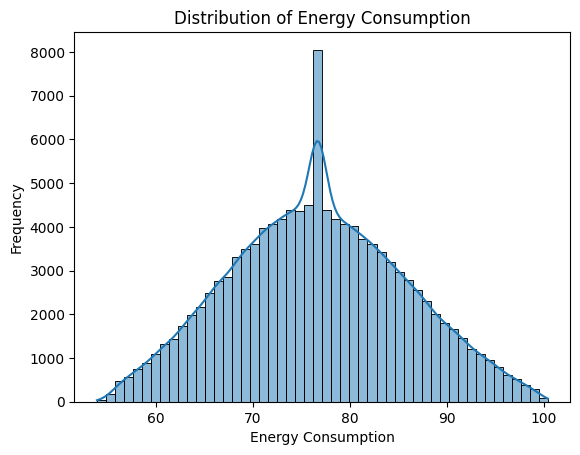

In [19]:
plt.figure()
sns.histplot(df['EnergyConsumption'], bins=50, kde=True)
plt.title("Distribution of Energy Consumption")
plt.xlabel("Energy Consumption")
plt.ylabel("Frequency")
plt.show()

#### Explanation
This diagram represents a statistical distribution of energy consumption data, visualized through a combination of a histogram and a smooth density curve. The horizontal axis (X-axis) tracks the amount of energy consumed, while the vertical axis (Y-axis) represents how often those specific amounts occur. The shape follows a Normal Distribution (or "bell curve"), meaning most data points are clustered in the center around 75–77 units, with fewer occurrences as you move toward the extreme low or high ends. The prominent vertical spike in the center indicates a high concentration of data at one specific value, while the smooth blue line (KDE) highlights the overall trend and density of the dataset, helping to identify the most common "typical" energy usage at a glance.

### Correlation Heatmap

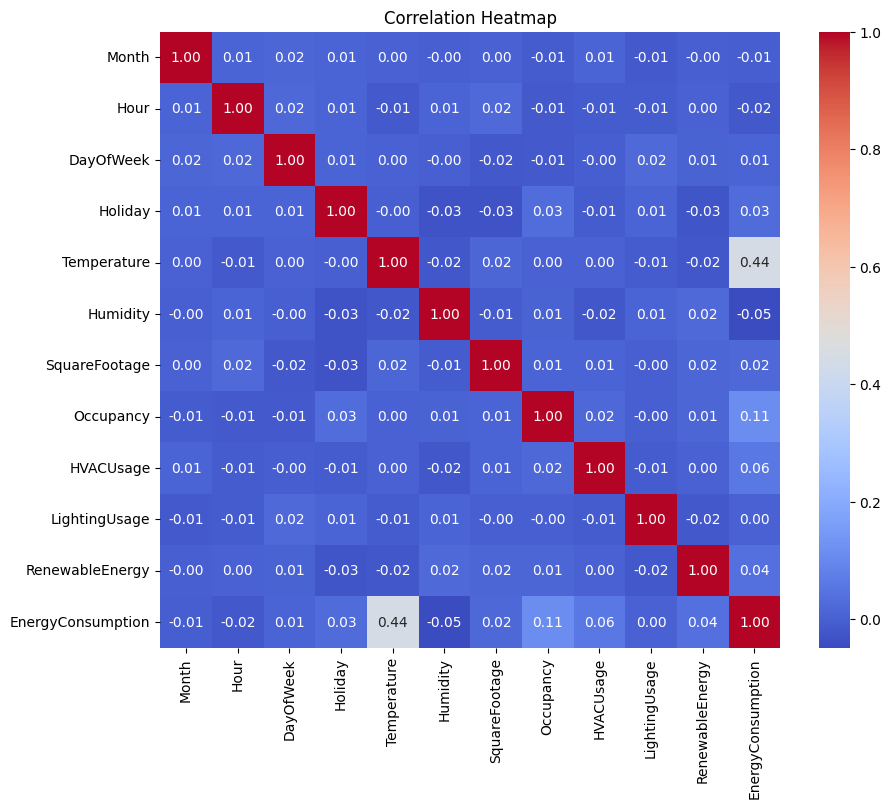

In [20]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

#### Explanation
This correlation heatmap illustrates the statistical relationships between various factors, where the color and numerical values indicate the strength and direction of these connections on a scale from -1.00 to 1.00. The prominent red diagonal represents a perfect correlation of 1.00, as every variable is identical to itself. Most of the map is dark blue, signifying that factors like Month, DayOfWeek, and Holiday have almost no impact on energy usage. The most significant finding is the moderate positive correlation of 0.44 between Temperature and EnergyConsumption, identifying temperature as the primary driver of energy use in this dataset. Additionally, a slight link of 0.12 exists for Occupancy, while almost all other variables remain independent of one another.

### Energy Consumption by Hour (Line Plot)

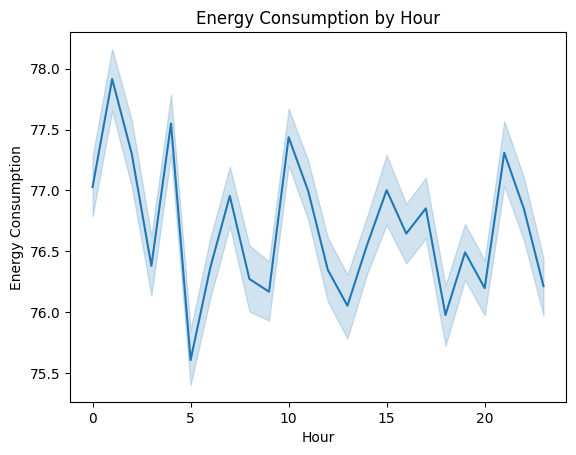

In [21]:
plt.figure()
sns.lineplot(x='Hour', y='EnergyConsumption', data=df)
plt.title("Energy Consumption by Hour")
plt.xlabel("Hour")
plt.ylabel("Energy Consumption")
plt.show()

#### Explanation
This line graph illustrates the fluctuations in Energy Consumption over a 24-hour cycle, where the dark blue line represents the average usage and the light blue shaded area indicates the confidence interval (the range of uncertainty or variation). The data shows a highly volatile pattern with several distinct peaks and valleys: consumption starts high at hour 1 (over 78 units), drops sharply to a daily low at hour 5 (roughly 75.4 units), and then experiences multiple surges throughout the day, notably at hours 10, 15, and 21. Because the Y-axis is zoomed in on a narrow range (75.5 to 78.0), even small changes appear as dramatic swings, revealing that while energy use is constantly shifting, it stays within a relatively tight window of about 3 units across the entire day.

### Energy Consumption by Day of Week (Boxplot)

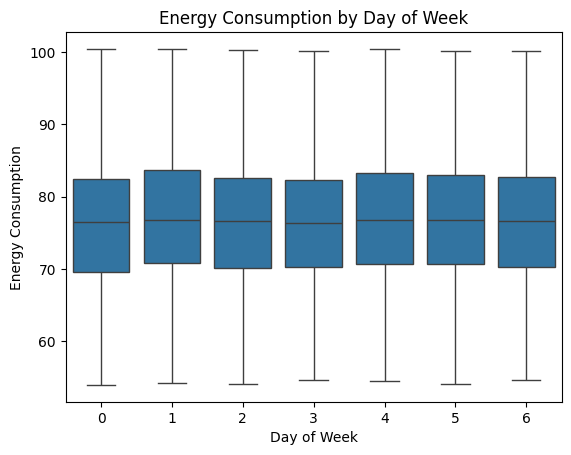

In [22]:
plt.figure()
sns.boxplot(x='DayOfWeek', y='EnergyConsumption', data=df, showfliers=False)
plt.title("Energy Consumption by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Energy Consumption")
plt.show()

#### Explanation
This Box Plot compares energy consumption across the seven days of the week (labeled 0 to 6), revealing that usage patterns are remarkably consistent regardless of the day. Each "box" represents the middle 50% of the data, with the horizontal line inside the box marking the median (average) consumption, which stays steady at approximately 77 units across all days. The vertical lines, or "whiskers," show the typical range of energy use from about 50 to 103 units, while the individual black dots at the very top and bottom represent outliers—unusual instances of exceptionally high or low energy consumption. Overall, the uniform height and position of these boxes indicate that the day of the week has virtually no impact on energy demand in this dataset.

### Energy Consumption on Holidays (Boxplot)

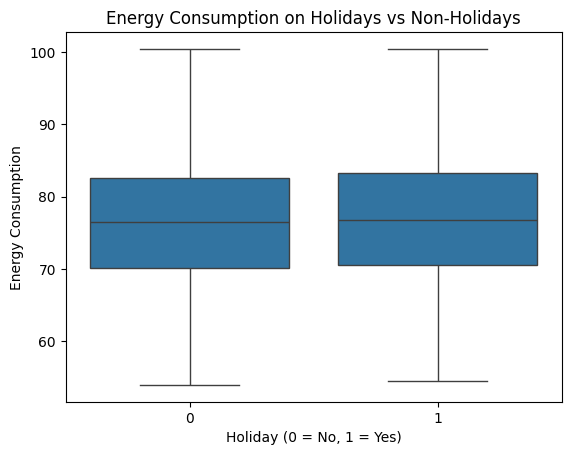

In [23]:
plt.figure()
sns.boxplot(x='Holiday', y='EnergyConsumption', data=df, showfliers=False)
plt.title("Energy Consumption on Holidays vs Non-Holidays")
plt.xlabel("Holiday (0 = No, 1 = Yes)")
plt.ylabel("Energy Consumption")
plt.show()

#### Explanation
This box plot compares energy consumption between non-holidays (0) and holidays (1), demonstrating that there is virtually no difference in energy usage patterns between these two categories. Both groups share an almost identical median energy consumption of approximately 77 units, and the "boxes," which represent the middle 50% of the data, occupy the same range from roughly 70 to 83 units. While both categories show a similar total range and include extreme outliers (individual dots at the top and bottom), the nearly identical size and placement of the two plots indicate that whether or not a day is a holiday has no significant impact on how much energy is consumed.

### Average Energy Consumption by Temperature Range

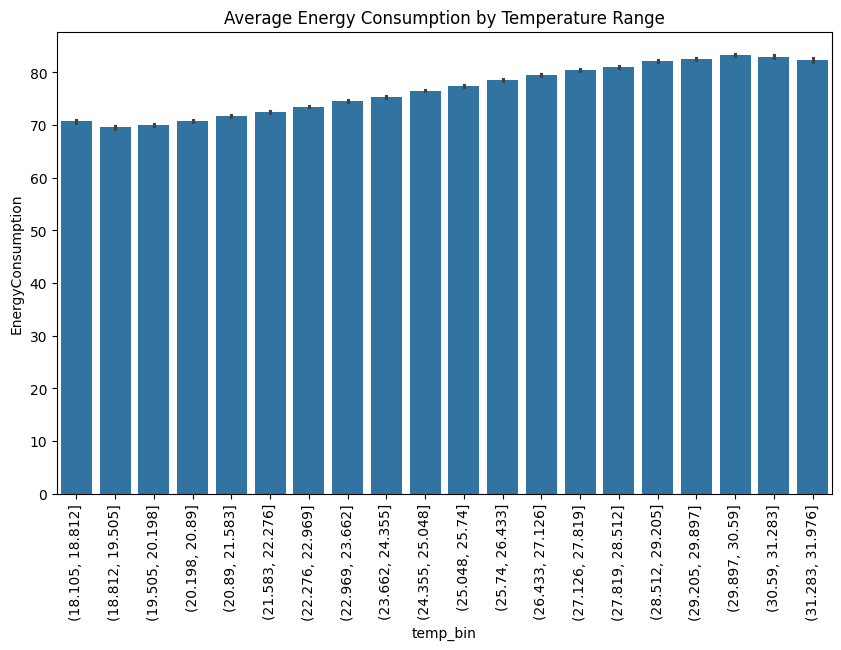

In [24]:
df['temp_bin'] = pd.cut(df['Temperature'], bins=20)

plt.figure(figsize=(10,6))
sns.barplot(x='temp_bin', y='EnergyConsumption', data=df)
plt.xticks(rotation=90)
plt.title("Average Energy Consumption by Temperature Range")
plt.show()

####
This bar chart illustrates a positive correlation between outdoor temperature and average energy consumption, showing that as temperatures rise, energy usage generally increases. The data is grouped into specific temperature bins (measured on the x-axis), starting from roughly 16°C and extending to nearly 35°C, with energy consumption (on the y-axis) climbing from approximately 70 units to over 80 units. While there is a slight dip or plateau in the cooler ranges between 17°C and 20°C, the trend becomes consistently upward thereafter, likely reflecting a higher demand for air conditioning as the weather gets hotter. The thin vertical black lines at the top of each bar represent error bars, which indicate the variability or uncertainty in the data for each specific temperature range; notably, the variability is highest at the extreme ends of the temperature spectrum.

### Average Energy Consumption by Hour

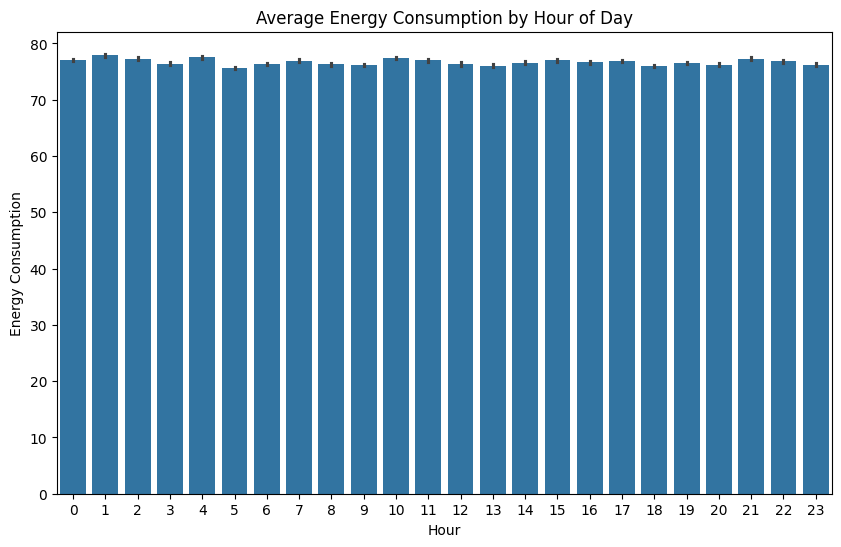

In [25]:
plt.figure(figsize=(10,6))
sns.barplot(x='Hour', y='EnergyConsumption', data=df, estimator='mean')
plt.title("Average Energy Consumption by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Energy Consumption")
plt.show()

#### Explanation
This chart shows that energy use stays very steady throughout the entire day. The bottom of the graph (the x-axis) represents the 24 hours of a day (from 0 to 23), and the height of the blue bars shows the average energy used during each hour. Unlike the temperature chart which showed big changes, this one is almost flat—energy consumption hover consistently between 75 and 80 units regardless of the time. Whether it is 2:00 AM (Hour 2) or 2:00 PM (Hour 14), the demand for electricity remains nearly the same. The tiny black lines on top of each bar show that there is very little variation in this pattern, meaning the energy needs are extremely predictable every hour of the day.